In [ ]:
import numpy as np
import pandas as pd

np.random.seed(42)

n = 1000

departments = ["HR", "IT", "Finance", "Sales", "Marketing", "Operations"]
education_levels = ["Diploma", "Bachelor", "Master", "PhD"]

# base employee data
data = pd.DataFrame({
    "employee_id": range(1, n + 1),
    "age": np.random.randint(21, 60, n),
    "department": np.random.choice(departments, n),
    "education_level": np.random.choice(education_levels, n),
    "training_hours": np.random.randint(0, 121, n)
})

# years of experience (linked to age)
data["years_experience"] = ((data["age"] - 21) * np.random.uniform(0.5, 0.9, n)).astype(int)

# performance score (1 to 5)
data["performance_score"] = np.clip(
    2 + 0.05 * data["years_experience"] + 0.02 * data["training_hours"],
    1, 5
).round(1)

# salary by department
base_salary = {
    "HR": 400000,
    "IT": 700000,
    "Finance": 800000,
    "Sales": 600000,
    "Marketing": 550000,
    "Operations": 500000
}

data["salary"] = (
    data["department"].map(base_salary)
    + data["years_experience"] * 30000
    + data["performance_score"] * 50000
).astype(int)

# promotion flag
data["promotion_last_2yrs"] = np.where(
    (data["performance_score"] >= 4) & (data["years_experience"] >= 5),
    "Yes", "No"
)

# attrition risk
data["attrition_risk"] = np.where(
    data["performance_score"] < 3, "High",
    np.where(data["performance_score"] < 4, "Medium", "Low")
)

wlb_base = {
    "HR": 4.2,
    "IT": 3.2,
    "Finance": 3.4,
    "Sales": 3.0,
    "Marketing": 3.6,
    "Operations": 3.8
}
data["wlb_score"] = np.clip(
    data["department"].map(wlb_base)
    - 0.01 * data["training_hours"]
    + np.random.normal(0, 0.3, len(data)),
    1, 5
).round(1)

print(data.head())

   employee_id  age department education_level  training_hours  \
0            1   59         IT        Bachelor             102   
1            2   49    Finance          Master              38   
2            3   35         HR          Master             113   
3            4   28    Finance         Diploma              34   
4            5   41    Finance          Master               0   

   years_experience  performance_score   salary promotion_last_2yrs  \
0                32                5.0  1910000                 Yes   
1                19                3.7  1555000                  No   
2                10                4.8   940000                 Yes   
3                 5                2.9  1095000                  No   
4                16                2.8  1420000                  No   

  attrition_risk  wlb_score  
0            Low        2.2  
1         Medium        2.6  
2            Low        3.0  
3           High        2.8  
4           High        3.

In [ ]:
data.describe()

,employee_id,age,training_hours,years_experience,performance_score,salary
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03
mean,500.500000,40.445000,60.879000,12.065000,3.680200,1.153523e+06
std,288.819436,11.499183,34.760763,8.084685,0.565746,2.843295e+05
min,1.000000,21.000000,0.000000,0.000000,1.900000,5.064590e+05
25%,250.750000,30.000000,31.000000,5.000000,3.300000,9.372008e+05
50%,500.500000,41.000000,61.000000,12.000000,3.700000,1.145658e+06
75%,750.250000,50.000000,90.250000,18.000000,4.100000,1.351091e+06
max,1000.000000,59.000000,120.000000,34.000000,5.000000,2.024660e+06


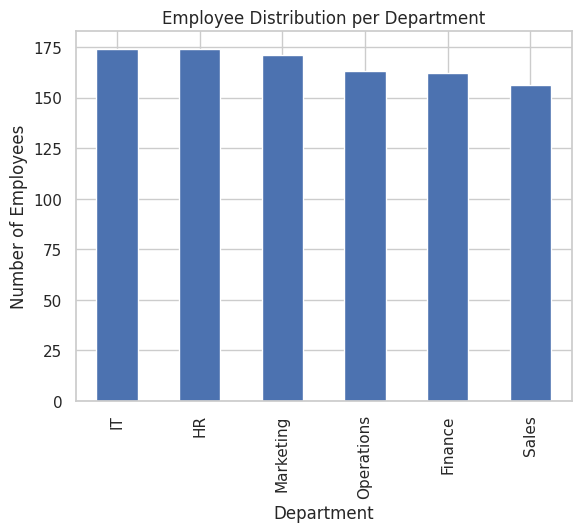

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# employee distribution per department

plt.figure()
data["department"].value_counts().plot(kind="bar")
plt.title("Employee Distribution per Department")
plt.xlabel("Department")
plt.ylabel("Number of Employees")
plt.show()


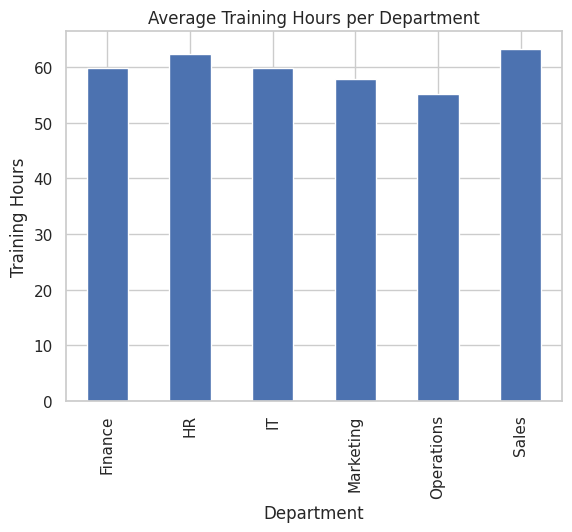

In [ ]:
# Learning Investment by Department

plt.figure()
data.groupby("department")["training_hours"].mean().plot(kind="bar")
plt.title("Average Training Hours per Department")
plt.xlabel("Department")
plt.ylabel("Training Hours")
plt.show()


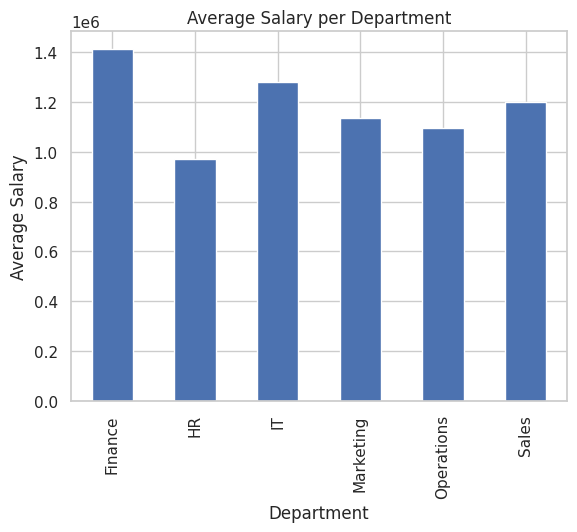

In [ ]:
# average salary per department

plt.figure()
data.groupby("department")["salary"].mean().plot(kind="bar")
plt.title("Average Salary per Department")
plt.xlabel("Department")
plt.ylabel("Average Salary")
plt.show()


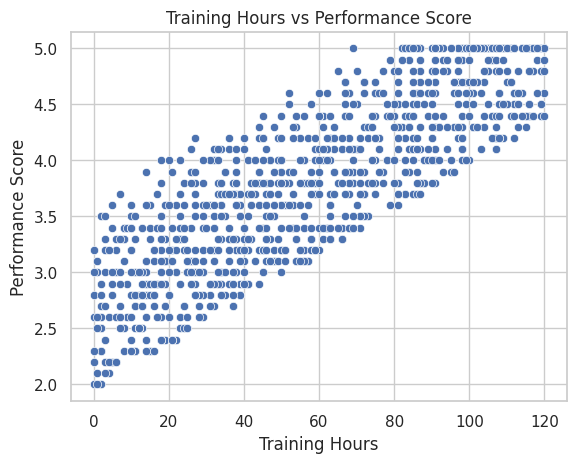

In [ ]:
# relationship between training and performance

plt.figure()
sns.scatterplot(
    x=data["training_hours"],
    y=data["performance_score"]
)
plt.title("Training Hours vs Performance Score")
plt.xlabel("Training Hours")
plt.ylabel("Performance Score")
plt.show()


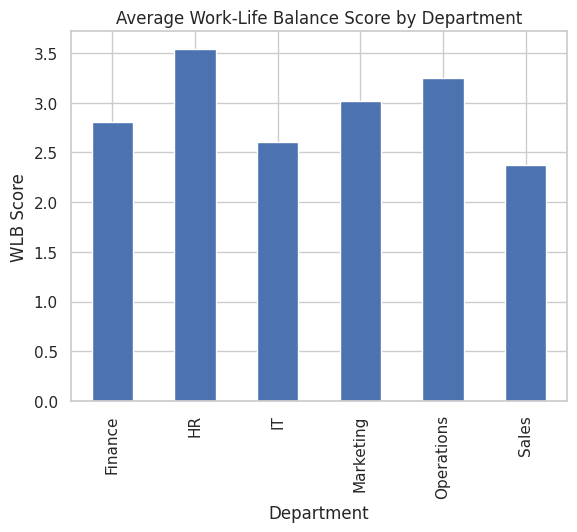

In [ ]:
# department-wise WLB health

plt.figure()
data.groupby("department")["wlb_score"].mean().plot(kind="bar")
plt.title("Average Work-Life Balance Score by Department")
plt.xlabel("Department")
plt.ylabel("WLB Score")
plt.show()


In [ ]:
# question 2
df = pd.read_csv("indian_food.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255 entries, 0 to 254
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   name            255 non-null    object
 1   ingredients     255 non-null    object
 2   diet            255 non-null    object
 3   prep_time       255 non-null    int64 
 4   cook_time       255 non-null    int64 
 5   flavor_profile  255 non-null    object
 6   course          255 non-null    object
 7   state           255 non-null    object
 8   region          254 non-null    object
dtypes: int64(2), object(7)
memory usage: 18.1+ KB


<Axes: xlabel='diet'>

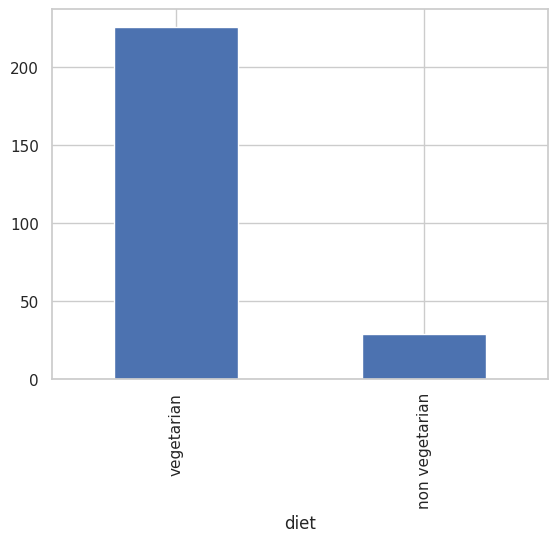

In [ ]:
# 1 count of vegeterian and non-vegeterian customers in bar graph
df["diet"].value_counts().plot(kind="bar")

<Axes: xlabel='flavor_profile'>

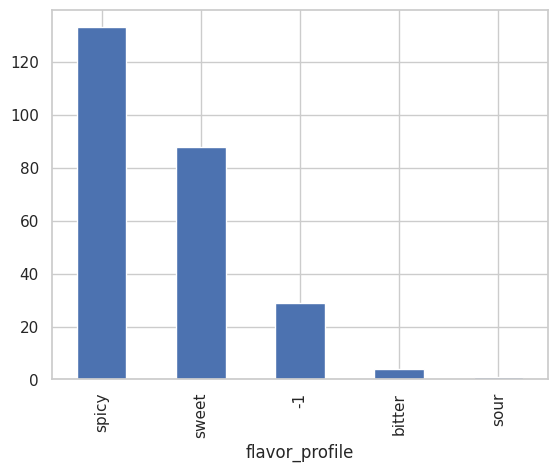

In [ ]:
# show the types of flaovor
df['flavor_profile'].value_counts().plot(kind="bar")

In [ ]:

print(f"Unique dishes: {df['name'].nunique()}")         # nunique() shows the the unique values with in the columns

 Unique dishes: 255
